<a href="https://colab.research.google.com/github/hfelizzola/Curso-Ciencia-de-Datos-con-Python/blob/main/4_machine_learning/6_Arboles_de_Decision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Arboles de Decisión

Este cuaderno contiene el código para la implementación de modelos de regresión logística en Python.

In [ ]:
# Cargar librerias para ciencia de datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Modulos librerias para aprendizaje de maquina
from sklearn.tree import DecisionTreeClassifier # Arbol de clasificación
from sklearn.tree import DecisionTreeRegressor # Arboles de regresión
from sklearn.linear_model import LogisticRegression # Regresión logística
from sklearn.tree import plot_tree, export_text # Gráficar árbol y extraer reglas
import graphviz # Graficar árbol
from yellowbrick.model_selection import feature_importances # Gráfica de variables
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split # División train/test
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # Matriz de confusión
from sklearn.metrics import classification_report # Reporte de métricas de clasificación
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error # Métricas de regresión

pd.set_option('display.max_columns', None)

In [ ]:
# Para conectarse con google drive
from google.colab import drive
drive.mount('/gdrive')
# Configurar directorio de trabajo
os.chdir('/gdrive/MyDrive/Colab Notebooks/Ciencia de Datos con Python')
# Verificar los archivos de las carpetas

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).


## Predicción de uso de cupones

In [ ]:
cupon = pd.read_csv("cupones.csv")
cupon.head()

,cliente,gasto,tarjeta,cupon
0,1,2.29,1,1
1,2,3.22,1,0
2,3,2.14,1,1
3,4,3.92,0,1
4,5,2.53,1,1


In [ ]:
# Selección X y Y
Y = cupon['cupon']

X = cupon[['gasto','tarjeta']]

In [ ]:
# Dividir los datos en cojunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, Y, train_size=0.7, random_state=7)

In [ ]:
# Entrenar arbol de clasificación
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [ ]:
# Orden las clases en el arbol
dt.classes_.astype('str')

array(['0', '1'], dtype='<U21')

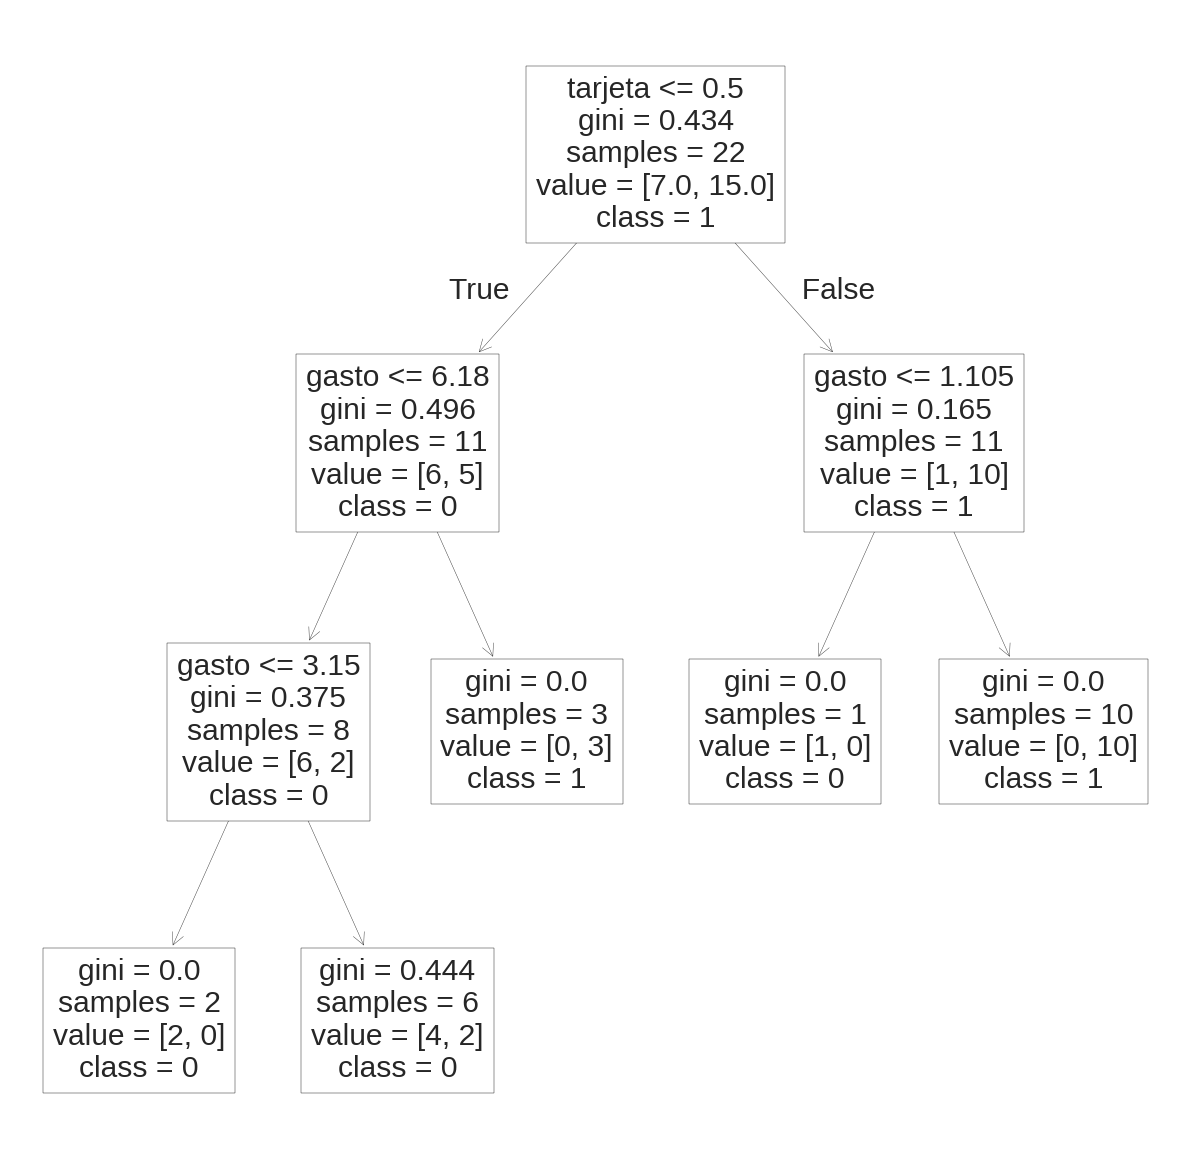

In [ ]:
# El siguiente codigo se utilizar para visualizar el árbol
plt.figure(figsize=(15,15))
plot_tree(dt, feature_names=X.columns, class_names=dt.classes_.astype('str'))
plt.show()

In [ ]:
# Extraer las reglas
text_representation = export_text(dt, feature_names=list(dt.feature_names_in_))
print(text_representation)

|--- tarjeta <= 0.50
|   |--- gasto <= 6.18
|   |   |--- gasto <= 3.15
|   |   |   |--- class: 0
|   |   |--- gasto >  3.15
|   |   |   |--- class: 0
|   |--- gasto >  6.18
|   |   |--- class: 1
|--- tarjeta >  0.50
|   |--- gasto <= 1.10
|   |   |--- class: 0
|   |--- gasto >  1.10
|   |   |--- class: 1



In [ ]:
# Generar predicciones
y_pred = dt.predict(X_test)

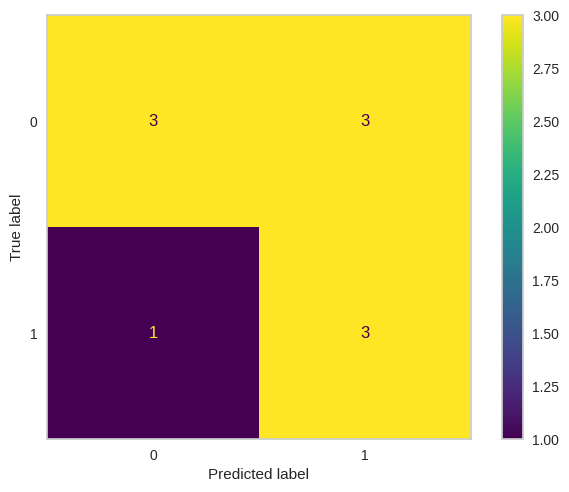

In [ ]:
# Generar matriz de confusión para conjunto de prueba
cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(cm).plot()
plt.grid(False)

In [ ]:
# Generar un reporte con las principales métricas.
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.50      0.60         6
           1       0.50      0.75      0.60         4

    accuracy                           0.60        10
   macro avg       0.62      0.62      0.60        10
weighted avg       0.65      0.60      0.60        10



## Caso. Incumplimiento en pago de tarjeta de crédito

**Contexto:** Este conjunto de datos contiene información de sobre incumplimientos de pagos en creditos, y entrega información de los clientes de acuerdo a factores demográficos, datos crediticios, historial de pagos y estados de cuenta de tarjetas de crédito.

**Objetivo:** Entrenar un clasificador basado en arboles de decisión el cual  permita construir reglas para detectar clientes en riesgo de default y estimar la probabilidad de esta categoría.

In [ ]:
datos_credito = pd.read_csv("incumplimiento_credito.csv")
datos_credito.head()

,saldo_cuenta(millones),duracion_prestamo_meses,historial_crediticio,proposito,monto(millones),saldo_ahorros(millones),antiguedad_empleo,tasa_cuotas,estado_personal,otros_deudores,historial_residencia,propiedad,edad,plan_cuotas,vivienda,creditos_existentes,trabajo,dependientes,telefono,trabajador_extranjero,incumplimiento
0,< 1M,6,crítico,radio/televisión,1169,desconocido,> 7 años,4,hombre soltero,ninguno,4,bienes raíces,67,ninguno,propia,2,empleado calificado,1,sí,sí,0
1,1M - 10M,48,pagado,radio/televisión,5951,< 1M,1 - 4 años,2,mujer,ninguno,2,bienes raíces,22,ninguno,propia,1,empleado calificado,1,ninguno,sí,1
2,desconocido,12,crítico,educación,2096,< 1M,4 - 7 años,2,hombre soltero,ninguno,3,bienes raíces,49,ninguno,propia,1,residente no calificado,2,ninguno,sí,0
3,< 1M,42,pagado,muebles,7882,< 1M,4 - 7 años,2,hombre soltero,aval,4,sociedad de ahorros y préstamos,45,ninguno,gratuita,1,empleado calificado,2,ninguno,sí,0
4,< 1M,24,retrasado,coche (nuevo),4870,< 1M,1 - 4 años,3,hombre soltero,ninguno,4,desconocido/nada,53,ninguno,gratuita,2,empleado calificado,2,ninguno,sí,1


In [ ]:
datos_credito.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   saldo_cuenta(millones)   1000 non-null   object
 1   duracion_prestamo_meses  1000 non-null   int64 
 2   historial_crediticio     1000 non-null   object
 3   proposito                1000 non-null   object
 4   monto(millones)          1000 non-null   int64 
 5   saldo_ahorros(millones)  1000 non-null   object
 6   antiguedad_empleo        1000 non-null   object
 7   tasa_cuotas              1000 non-null   int64 
 8   estado_personal          1000 non-null   object
 9   otros_deudores           1000 non-null   object
 10  historial_residencia     1000 non-null   int64 
 11  propiedad                1000 non-null   object
 12  edad                     1000 non-null   int64 
 13  plan_cuotas              1000 non-null   object
 14  vivienda                 1000 non-null   

## Regresión logística

### Preparar los datos

In [ ]:
# Divida variables independientes Xs y variable dependiente y
Y = datos_credito['incumplimiento']
X = datos_credito.drop(columns=['incumplimiento'])

In [ ]:
# Cree las variables dummies
X = pd.get_dummies(X)

In [ ]:
# Dividir los datos en cojunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, Y, train_size=0.7, random_state=7)

### Entrenar el modelo

In [ ]:
# Entrenar el modelo de regresión
regresion_logistica = LogisticRegression(max_iter=1000)
regresion_logistica.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

Cuando se tiene una gran cantidad de variables se puede generar una gráfica de importancia de variables:

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/yellowbrick/model_selection/importances.py:194: YellowbrickWarning: detected multi-dimensional feature importances but stack=False, using mean to aggregate them.
  warnings.warn(


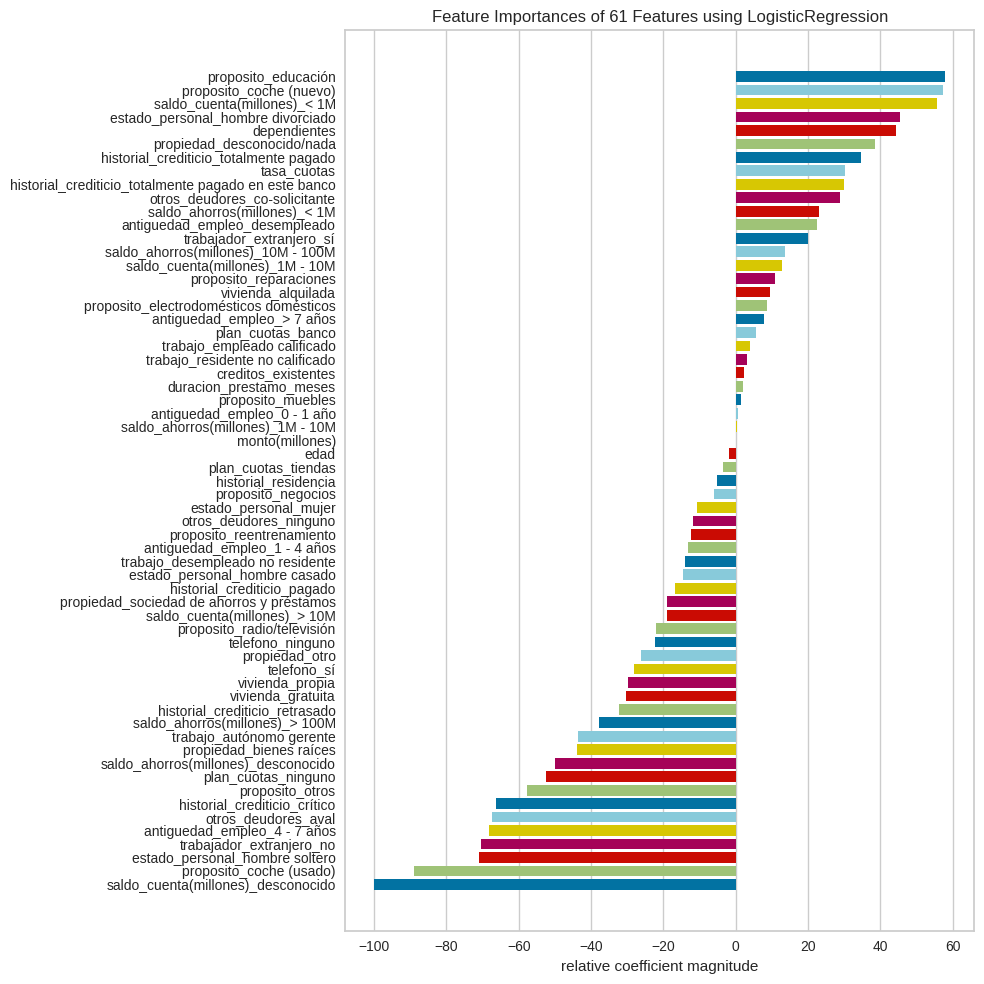

FeatureImportances(ax=<Axes: title={'center': 'Feature Importances of 61 Features using LogisticRegression'}, xlabel='relative coefficient magnitude'>,
                   estimator=LogisticRegression(max_iter=1000))

In [ ]:
# Gráfica de importancia de variables
plt.figure(figsize=(10,10))
feature_importances(LogisticRegression(max_iter=1000), X_train, y_train)

### Desempeño de la regresión logística

In [ ]:
# Generar predicciones
y_pred = regresion_logistica.predict(X_test)

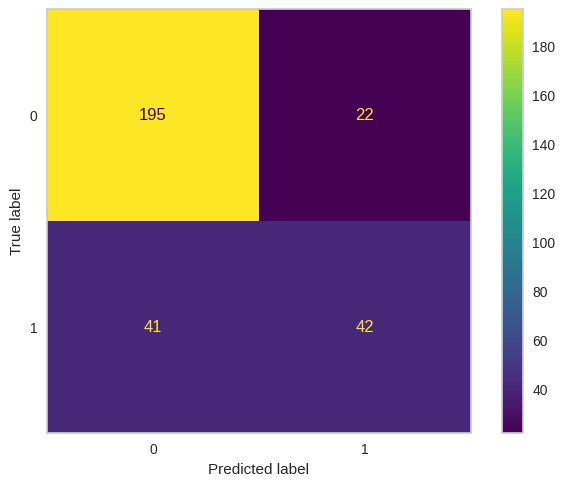

In [ ]:
# Generar matriz de confusión para conjunto de prueba
cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(cm).plot()
plt.grid(False)

In [ ]:
# Generar un reporte con las principales métricas.
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86       217
           1       0.66      0.51      0.57        83

    accuracy                           0.79       300
   macro avg       0.74      0.70      0.72       300
weighted avg       0.78      0.79      0.78       300



## Arbol de Clasificación

### Entrenamiento

In [ ]:
# Configurar el árbol y entrenar


### Análisis de variables y predicciones

In [ ]:
# Extraer las reglas


In [ ]:
# Gráfica de importancia de variables
# plt.figure(figsize=(10,10))
# feature_importances(DecisionTreeClassifier(max_depth=3) , X_train, y_train)

In [ ]:
# Generar predicciones


In [ ]:
# Generar matriz de confusión para conjunto de prueba


In [ ]:
# Generar un reporte con las principales métricas.


**Compare el desempeño de la regresión logística con el arbol de clasificación ¿Qué modelo funciona mejor? ¿Qué aspectos**

### Optimización de hiperparámetros

In [ ]:
# Crear un modelo base para la busqueda de hiperparametros
dt_model_cv = DecisionTreeClassifier()

# Crear un grid de busqueda
dt_grid = {"max_depth": np.arange(2, 22)}

# Configurar la busqueda
dt_tunning = GridSearchCV(estimator=dt_model_cv,
                          param_grid=dt_grid,
                          cv=5,
                          scoring="recall",
                          return_train_score=True)

# Realizar la busqueda
dt_tunning.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21])},
             return_train_score=True, scoring='recall')

In [ ]:
# Guardar los resultados de la busqueda
dt_cv_results = pd.DataFrame(dt_tunning.cv_results_)
dt_cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.003787,0.000603,0.003400,0.000421,2,{'max_depth': 2},0.227273,0.000000,0.000000,0.069767,0.069767,0.073362,0.083040,20,0.300578,0.000000,0.000000,0.258621,0.103448,0.132529,0.126581
1,0.003429,0.000049,0.003020,0.000051,3,{'max_depth': 3},0.204545,0.068182,0.395349,0.069767,0.372093,0.221987,0.141221,19,0.317919,0.190751,0.505747,0.258621,0.517241,0.358056,0.131637
2,0.003847,0.000070,0.003150,0.000034,4,{'max_depth': 4},0.272727,0.272727,0.372093,0.162791,0.209302,0.257928,0.070551,18,0.462428,0.433526,0.534483,0.477011,0.275862,0.436662,0.086865
3,0.004227,0.000075,0.003177,0.000085,5,{'max_depth': 5},0.272727,0.250000,0.372093,0.069767,0.465116,0.285941,0.132456,17,0.485549,0.445087,0.557471,0.413793,0.609195,0.502219,0.071914
4,0.004545,0.000087,0.003212,0.000070,6,{'max_depth': 6},0.295455,0.363636,0.441860,0.186047,0.372093,0.331818,0.086389,16,0.595376,0.595376,0.695402,0.568966,0.511494,0.593323,0.059528
5,0.004752,0.000105,0.003284,0.000500,7,{'max_depth': 7},0.295455,0.318182,0.511628,0.209302,0.465116,0.359937,0.111951,15,0.664740,0.572254,0.655172,0.655172,0.603448,0.630157,0.036093
6,0.005343,0.000668,0.003176,0.000139,8,{'max_depth': 8},0.386364,0.340909,0.418605,0.395349,0.488372,0.405920,0.048332,14,0.751445,0.641618,0.706897,0.787356,0.775862,0.732636,0.053223
7,0.005260,0.000249,0.003043,0.000062,9,{'max_depth': 9},0.363636,0.386364,0.511628,0.395349,0.511628,0.433721,0.064445,13,0.815029,0.699422,0.804598,0.850575,0.862069,0.806338,0.057572
8,0.005303,0.000218,0.003130,0.000187,10,{'max_depth': 10},0.522727,0.409091,0.581395,0.348837,0.418605,0.456131,0.083975,12,0.953757,0.716763,0.867816,0.885057,0.856322,0.855943,0.077366
9,0.005456,0.000132,0.003029,0.000119,11,{'max_depth': 11},0.454545,0.500000,0.558140,0.372093,0.418605,0.460677,0.064343,11,0.959538,0.849711,0.965517,0.971264,0.902299,0.929666,0.047010


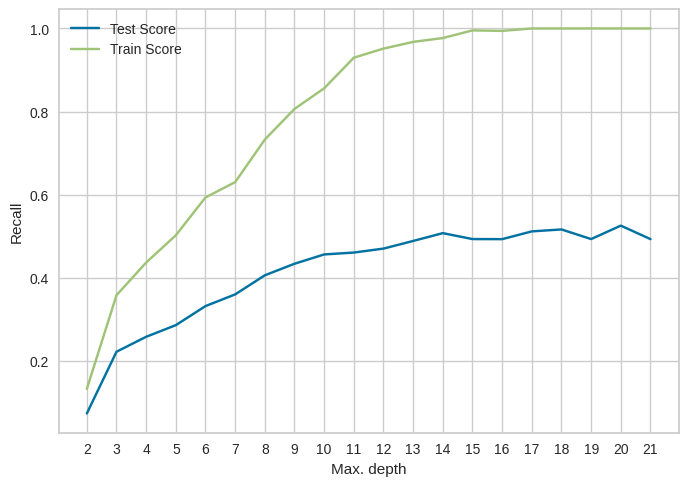

In [ ]:
# Curva de validación
plt.plot(dt_cv_results['param_max_depth'], dt_cv_results['mean_test_score'], label="Test Score")
plt.plot(dt_cv_results['param_max_depth'], dt_cv_results['mean_train_score'], label="Train Score")
plt.xticks(dt_cv_results['param_max_depth'])
plt.xlabel("Max. depth")
plt.ylabel("Recall")
plt.legend()
plt.show()

In [ ]:
# Imprimir el paramétro con el mejor desempeño
print(f'max_depth: {dt_tunning.best_params_}')
dt_tunning.best_score_

max_depth: {'max_depth': np.int64(20)}


np.float64(0.525475687103594)

### Entrenar con parámetro óptimo

In [ ]:
# Configurar el árbol y entrenar
dt_optimizado = DecisionTreeClassifier(**dt_tunning.best_params_)
dt_optimizado.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=np.int64(20))

In [ ]:
# Generar predicciones
y_pred_dt_opt = dt_optimizado.predict(X_test)

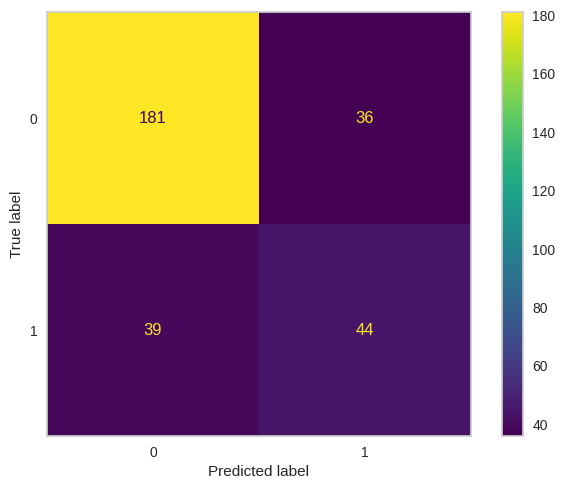

In [ ]:
# Generar matriz de confusión para conjunto de prueba
cm = confusion_matrix(y_test, y_pred_dt_opt)
cm_display = ConfusionMatrixDisplay(cm).plot()
plt.grid(False)

In [ ]:
# Generar un reporte con las principales métricas con max_depth=10.
print(classification_report(y_test, y_pred_dt_opt))

              precision    recall  f1-score   support

           0       0.82      0.83      0.83       217
           1       0.55      0.53      0.54        83

    accuracy                           0.75       300
   macro avg       0.69      0.68      0.68       300
weighted avg       0.75      0.75      0.75       300



In [ ]:
# Generar un reporte con las principales métricas con max_depth=3.


## Arboles de regresión. Estimación de gastos médicos

Construya un árbol de regresión para estimar los gastos de médicos.

1. Ajuste el el hiperparámetro de profundidad del arbol (`max_depth`) para minimizar el MSE.
2. Luego entrene el árbol de regresión el valor optimo de profundidad.
3. Evalue las predicciones teniendo en cuenta el MSE, RMSE y MAPE.
4. Analice las predicciones y compare los resultados del árbol con el modelo de regresión lineal. Cual de estos modelos genera mejores predicciones.
5. Tambien haga una análisis de variables más importantes.

**Nota:** Recuerde que para el árbol de regresión se deben utilizar

In [ ]:
gastos = pd.read_excel("gastos_medicos.xlsx")
gastos.head(10)

,sexo,edad,hijos,region,imc,fumador,gastos
0,mujer,19,0,suroccidente,27.900,si,16884.92
1,hombre,18,1,suroriente,33.770,no,1725.55
2,hombre,28,3,suroriente,33.000,no,4449.46
3,hombre,33,0,noroccidente,22.705,no,21984.47
4,hombre,32,0,noroccidente,28.880,no,3866.86
5,mujer,31,0,suroriente,25.740,no,3756.62
6,mujer,46,1,suroriente,33.440,no,8240.59
7,mujer,37,3,noroccidente,27.740,no,7281.51
8,hombre,37,2,nororiente,29.830,no,6406.41
9,mujer,60,0,noroccidente,25.840,no,28923.14
